Import libraries

In [ ]:
import numpy as np #for numerical data
import pandas as pd #for creating and working with dataframes
import matplotlib.pyplot as plt #for creating plots & charts
import seaborn as sns #for creating statistical visualizations

from sklearn.datasets import load_iris #for loading the Iris dataset

sns.set_theme(style="whitegrid") #to make plots more clear

print("Librares imported successfully")

Librares imported successfully


1. Load the Iris dataset into a DataFrame.

In [ ]:
iris = load_iris() #liad dataset

#convert the numerical iris data inot pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

df["species_id"] = iris.target #add numerical target for each flower

#convert numerical species id's into readable species names
df["species"]= df["species_id"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})
print("iris dataset loaded successfully")

iris dataset loaded successfully


2. Display the first 10 rows, shape, columns, missing values, and descriptive statistics.

In [ ]:
print("1st 10 rows")
display(df.head(10))

print("\nDataser shape")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing val in each column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

1st 10 rows


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa



Dataser shape
(150, 6)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species_id', 'species']

Missing val in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species              0
dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


3. Create at least two new derived columns.

In [ ]:
# Create a new derived column for petal area
# Multiply petal length by petal width
df["petal_area"] = df["petal length (cm)"] * df["petal width (cm)"]


# Create a new derived column for sepal area
# Multiply sepal length by sepal width
df["sepal_area"] = df["sepal length (cm)"] * df["sepal width (cm)"]


# Display the first 5 rows of the new derived columns
print("New derived columns:")
display(df[["petal_area", "sepal_area"]].head())


# Display the shape after adding the new columns
print("Shape after feature creation:")
print(df.shape)

New derived columns:


,petal_area,sepal_area
0,0.28,17.85
1,0.28,14.70
2,0.26,15.04
3,0.30,14.26
4,0.28,18.00


Shape after feature creation:
(150, 8)


4. Create three filtered DataFrames.

In [ ]:
# Create a DataFrame with flowers that have petal width greater than 1.5 cm
wide_petals = df[df["petal width (cm)"] > 1.5].copy()


# Create a DataFrame that contains only Virginica flowers
virginica_only = df[df["species"] == "virginica"].copy()


# Create a DataFrame using two conditions:
# sepal length greater than 6 cm AND petal width greater than 1.5 cm
combined_filter = df[
    (df["sepal length (cm)"] > 6) &
    (df["petal width (cm)"] > 1.5)
].copy()


# Display the shape of each filtered DataFrame
print("Wide petals:", wide_petals.shape)
print("Virginica:", virginica_only.shape)
print("Combined filter:", combined_filter.shape)

Wide petals: (52, 8)
Virginica: (50, 8)
Combined filter: (41, 8)


5. Use groupby() to compare at least two features by species.

In [ ]:
# Group the dataset by species and calculate the average
# petal length, petal width, and petal area for each species
species_summary = df.groupby("species")[["petal length (cm)", "petal width (cm)", "petal_area"]].mean()

# Display the comparison between the three species
print("Average features by species:")
display(species_summary)

Average features by species:


,petal length (cm),petal width (cm),petal_area
species,,,
setosa,1.462,0.246,0.3656
versicolor,4.260,1.326,5.7204
virginica,5.552,2.026,11.2962


6.1 Create one Matplotlib scatter

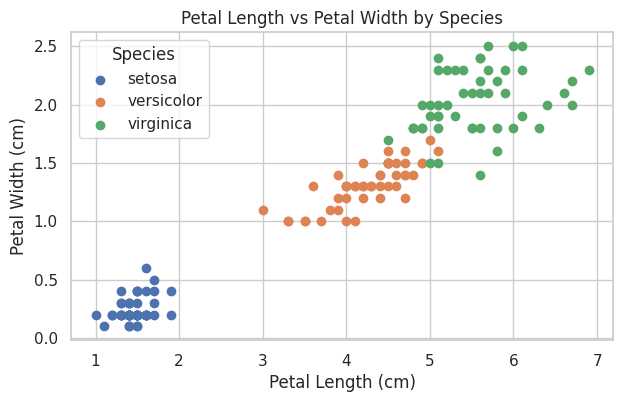

In [ ]:
# Create a scatter plot to compare petal length and petal width
plt.figure(figsize=(7, 4))


# Group the flowers by species and plot each species separately
for species, group in df.groupby("species"):
    plt.scatter(
        group["petal length (cm)"],
        group["petal width (cm)"],
        label=species
    )


# Add labels and a title to the scatter plot
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width by Species")


# Add a legend to show the three species
plt.legend(title="Species")


# Display the scatter plot
plt.show()

6.2 Create one Matplotlib histogram

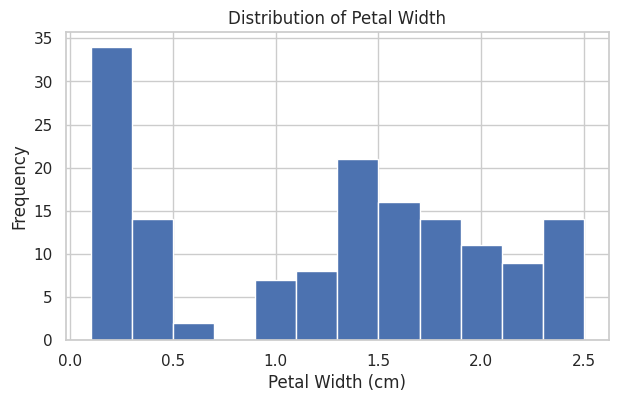

In [ ]:
# Create a histogram to show the distribution of petal width
plt.figure(figsize=(7, 4))


# Plot the distribution of petal width using 12 bins
plt.hist(df["petal width (cm)"], bins=12)


# Add labels and a title to the histogram
plt.xlabel("Petal Width (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of Petal Width")


# Display the histogram
plt.show()

7.١ Create one Seaborn boxplot

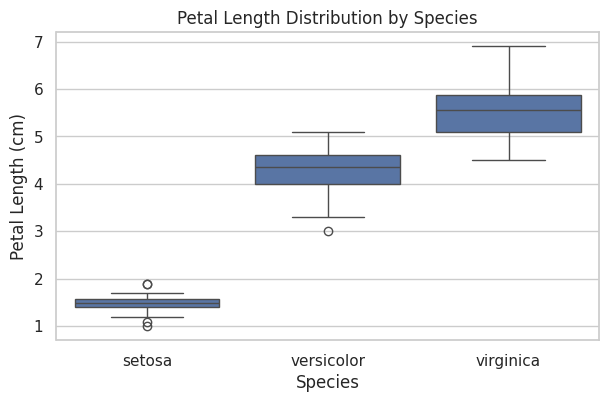

In [ ]:
# Create a boxplot to compare petal length between the three species
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)"
)

# Add labels and a title to the boxplot
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.title("Petal Length Distribution by Species")

# Display the boxplot
plt.show()

7.2 Create one Seaborn heatmap

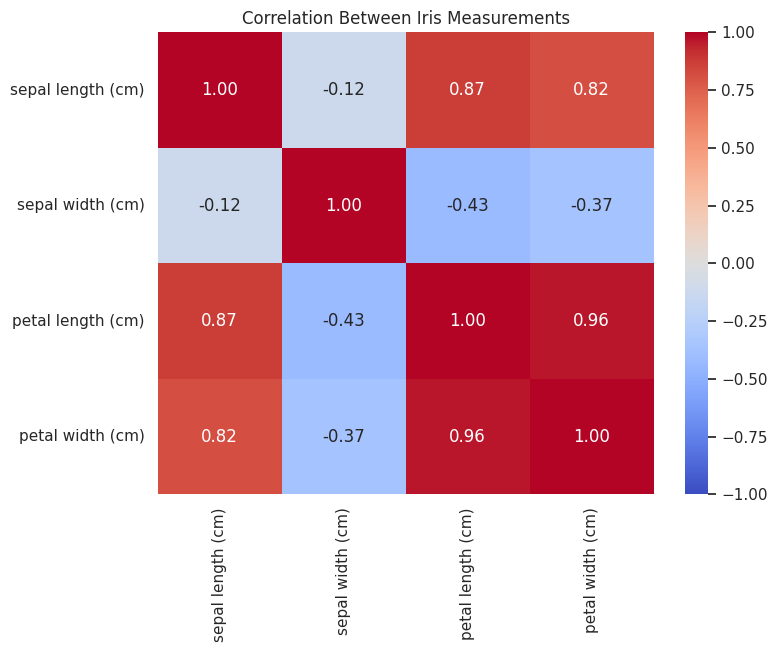

In [ ]:
# Select the four original numerical measurements
original_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]


# Calculate the correlation between the original numerical features
correlation = df[original_features].corr()


# Create a heatmap to display the correlations
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)


# Add a title to the heatmap
plt.title("Correlation Between Iris Measurements")


# Display the heatmap
plt.show()

8. Create or improve an OOP class with at least four methods.

In [ ]:
# Create a class for analyzing the Iris dataset
class IrisAnalyzer:

    # Initialize the class with the dataset
    def __init__(self, data):
        self.data = data

    # Method 1: Return the shape of the dataset
    def show_shape(self):
        return self.data.shape

    # Method 2: Count the number of flowers in each species
    def species_counts(self):
        return self.data["species"].value_counts()

    # Method 3: Calculate the average of a feature for each species
    def feature_mean_by_species(self, feature):
        return self.data.groupby("species")[feature].mean()

    # Method 4: Calculate the maximum value of a feature for each species
    def feature_max_by_species(self, feature):
        return self.data.groupby("species")[feature].max()


# Create an object from the IrisAnalyzer class
analyzer = IrisAnalyzer(df)


# Test the methods
print("Dataset shape:")
print(analyzer.show_shape())

print("\nNumber of flowers in each species:")
print(analyzer.species_counts())

print("\nAverage petal length by species:")
print(analyzer.feature_mean_by_species("petal length (cm)"))

print("\nMaximum petal length by species:")
print(analyzer.feature_max_by_species("petal length (cm)"))

Dataset shape:
(150, 8)

Number of flowers in each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Average petal length by species:
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

Maximum petal length by species:
species
setosa        1.9
versicolor    5.1
virginica     6.9
Name: petal length (cm), dtype: float64


### **9.1 The most important data pattern**

The main pattern I noticed in the Iris dataset is the difference in petal size between the three species. Setosa has the smallest petals, while Virginica has the largest. Versicolor and Virginica are more similar to each other. I could see these differences clearly in the scatter plot and boxplot.

### **9.2 How this lab prepares you for future AI topics.**

This lab helped me understand some of the steps that are needed before building a machine learning model. I learned how to explore a dataset, check for missing values, create new features, filter and group the data, and use visualizations to find patterns. Creating new columns such as petal area also gave me a simple idea of feature engineering, which can be useful later when preparing data for AI models.